## Unsupervised Learning on Country Data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\archive (2)\Country-data.csv")

In [82]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, explorative = True)
profile.to_file("HELP NGO DATA.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 27.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
df.corr(numeric_only = True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [6]:
X =df.drop(['country', "income"],axis = 1)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size = 0.25, random_state = 42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_train_scaled)


In [9]:
from sklearn.cluster import KMeans

In [10]:
wcss = []
for i in range (1,11):
    kmean = KMeans(n_clusters = i,random_state = 42)
    kmean.fit(X_pca)
    wcss.append(kmean.inertia_)

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

In [11]:
wcss

[633.0820588768429,
 328.8571067971261,
 245.83928229934162,
 198.67541143375857,
 174.27435020905816,
 149.23865311684114,
 102.27117215786132,
 94.63173824494761,
 78.500342761283,
 69.56659299731122]

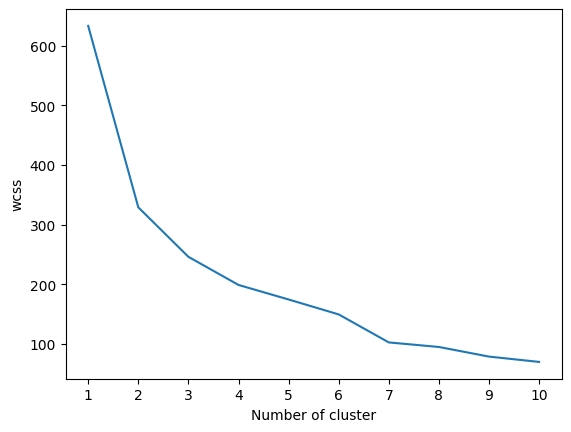

In [12]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of cluster")
plt.ylabel('wcss')
plt.show()

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

k=2: Silhouette=0.4303
k=3: Silhouette=0.3793
k=4: Silhouette=0.3240
k=5: Silhouette=0.2943
k=6: Silhouette=0.3009


c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

k=7: Silhouette=0.3490
k=8: Silhouette=0.3104
k=9: Silhouette=0.3294
k=10: Silhouette=0.3334


c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


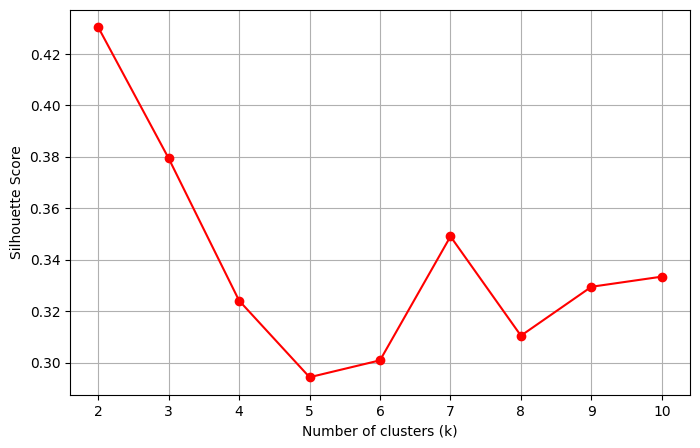

In [13]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11): 
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil)
    print(f"k={i}: Silhouette={sil:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, 'ro-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [14]:
kmean = KMeans(n_clusters = 2, init = 'k-means++')
y_labels = kmean.fit_predict(X_pca)

c:\Users\Ali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


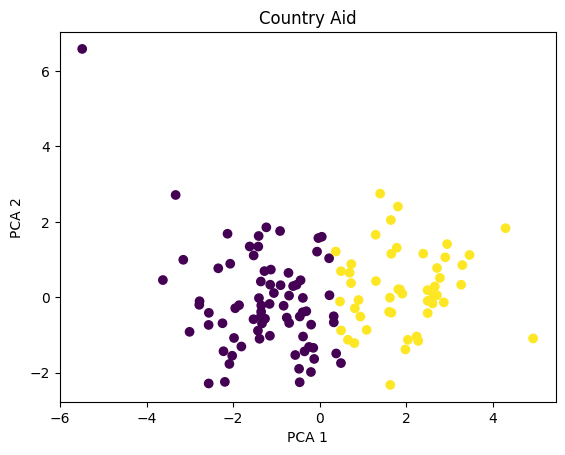

In [15]:
plt.scatter(X_pca[: , 0],X_pca[: , 1], c= y_labels)
plt.title("Country Aid")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Fixing Centroid to Data_point**

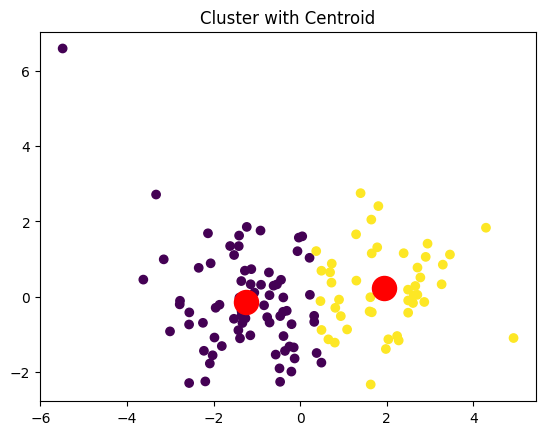

In [16]:
plt.scatter(X_pca[:, 0], X_pca[:,1],c=y_labels)
plt.scatter(kmean.cluster_centers_[:,0], kmean.cluster_centers_[:,1], s = 300, c ="red", marker = "o")
plt.title("Cluster with Centroid")
plt.show()

**Clustering on original features**

In [17]:
X_train['cluster']= y_labels

In [18]:
cluster_summary = X_train.groupby('cluster').mean()
print(cluster_summary)

         child_mort    exports    health    imports  inflation  life_expec  \
cluster                                                                      
0         12.563158  45.396053  7.477895  46.153947   6.071895   76.007895   
1         82.451020  29.989776  5.764082  42.552365  12.557653   61.010204   

         total_fer          gdpp  
cluster                           
0         2.006579  20381.263158  
1         4.587551   1985.408163  


In [19]:
df_train = df.loc[X_train.index].copy()
df_train['cluster'] = y_labels

In [20]:
aid_countries = df_train[df_train['cluster']==1]
aid_countries[['country', 'gdpp', 'child_mort', 'life_expec']]

,country,gdpp,child_mort,life_expec
94,Malawi,459,90.5,53.1
36,Comoros,769,88.2,65.9
66,Haiti,662,208.0,32.1
97,Mali,708,137.0,59.5
146,Tajikistan,738,52.4,69.6
38,"Congo, Rep.",2740,63.9,60.4
32,Chad,897,150.0,56.5
112,Niger,348,123.0,58.8
69,India,1350,58.8,66.2
155,Uganda,595,81.0,56.8


In [21]:
top15 = aid_countries.sort_values(by='child_mort', ascending=False).head(15)
print(top15[['country', 'gdpp', 'child_mort', 'life_expec']])

               country   gdpp  child_mort  life_expec
66               Haiti    662       208.0        32.1
32                Chad    897       150.0        56.5
97                Mali    708       137.0        59.5
113            Nigeria   2330       130.0        60.5
112              Niger    348       123.0        58.8
3               Angola   3530       119.0        60.1
25        Burkina Faso    575       116.0        57.9
37    Congo, Dem. Rep.    334       116.0        57.5
64       Guinea-Bissau    547       114.0        55.6
49   Equatorial Guinea  17100       111.0        60.9
17               Benin    758       111.0        61.8
40       Cote d'Ivoire   1220       111.0        56.3
63              Guinea    648       109.0        58.0
28            Cameroon   1310       108.0        57.3
106         Mozambique    419       101.0        54.5


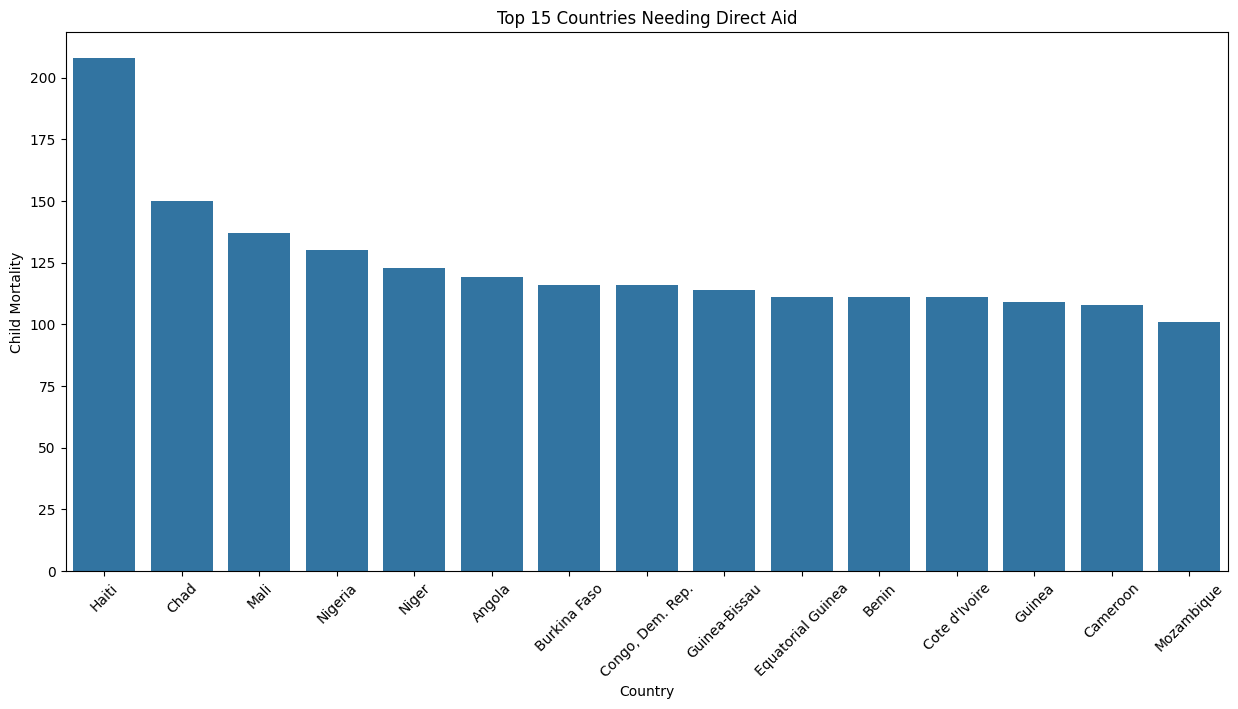

In [22]:
plt.figure(figsize=(15,7))

top15 = aid_countries.sort_values(by='child_mort', ascending=False).head(15)

sns.barplot(
    data=top15,
    x='country',
    y='child_mort'
)

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Child Mortality")
plt.title("Top 15 Countries Needing Direct Aid")
plt.show()

In [23]:
X_train['cluster'].value_counts()

cluster
0    76
1    49
Name: count, dtype: int64

In [24]:
silhouette_score(X_pca, y_labels)

0.4348669079938363

**Apply PCA and KMEAN on TEST data**

In [25]:
X_test_pca = pca.transform(X_test_scaled)
test_label = kmean.predict(X_test_pca)

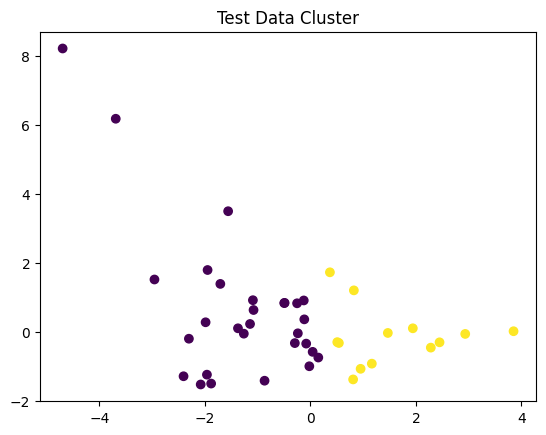

In [26]:
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c = test_label)
plt.title("Test Data Cluster")
plt.show()

## Hierarchial Clustering

In [27]:
import scipy.cluster.hierarchy as sc

Text(0, 0.5, 'euclidean distance')

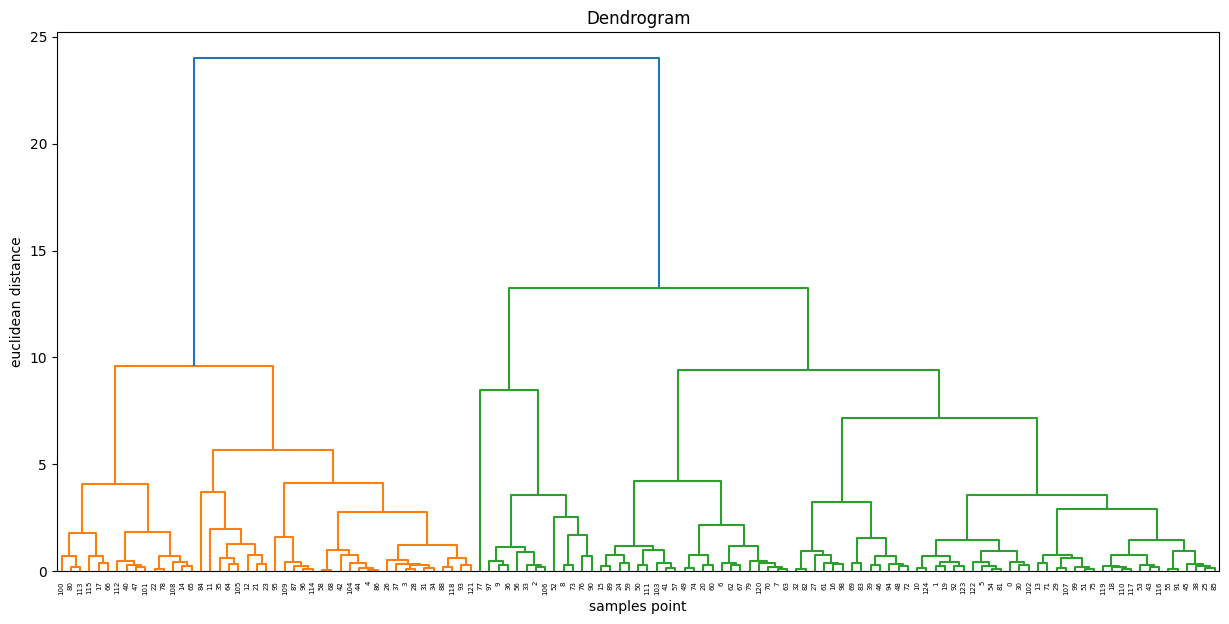

In [29]:
plt.figure(figsize = (15,7))
plt.title('Dendogram')
sc.dendrogram(sc.linkage(X_pca,method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('samples point')
plt.ylabel('euclidean distance')

In [30]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean',linkage = 'ward')
cluster.fit(X_pca)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [31]:
cluster.labels_

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

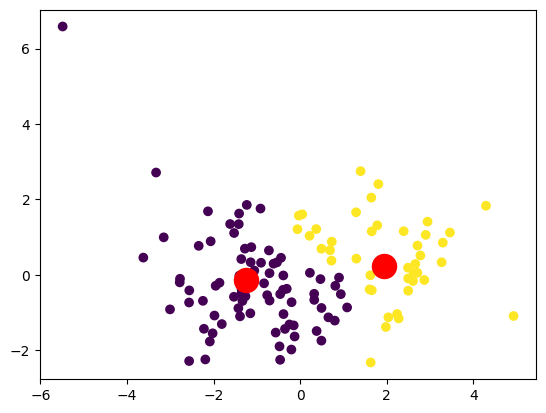

In [34]:
plt.scatter(X_pca[:,0], X_pca[:,1],c= cluster.labels_)
plt.scatter(kmean.cluster_centers_[:,0],kmean.cluster_centers_[:,1], s = 300, c = 'red', marker = 'o')
plt.show()

In [35]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range (2,11):
   cluster = AgglomerativeClustering(n_clusters = k, metric = 'euclidean', linkage = 'ward')
   cluster.fit(X_pca)
   score = silhouette_score(X_pca, cluster.labels_)
   print(score)
   silhouette_scores.append(score)


0.42157789878471524
0.3863227229053383
0.36121095083424676
0.3386888934096194
0.3369011884369874
0.3623998154253677
0.35316625828666226
0.3354489332403059
0.35356223516530233


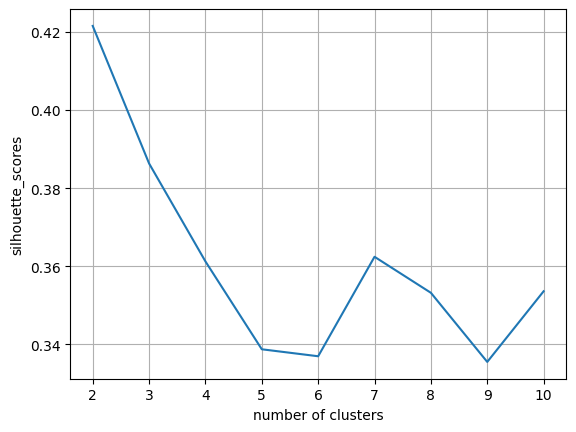

In [36]:
plt.plot(range(2,11), silhouette_scores)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette_scores")
plt.grid(True)
plt.show()

## DBSCAN

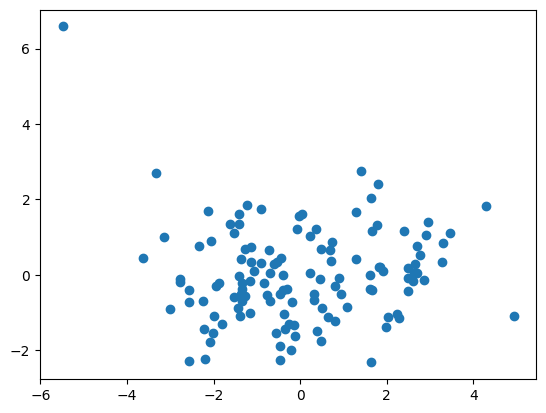

In [38]:
from sklearn.cluster import DBSCAN
plt.scatter(X_pca[:,0],X_pca[:,1])

In [82]:
dbs = DBSCAN(eps = 1,min_samples = 2, metric= 'euclidean')
dbs.fit(X_pca)

,eps,1
,min_samples,2
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [83]:
dbs.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0])

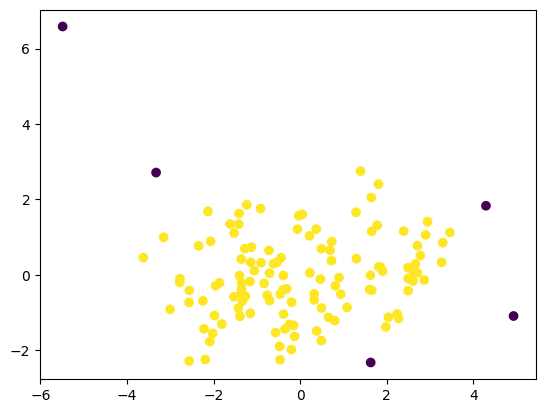

In [84]:
plt.scatter(X_pca[:,0],X_pca[:,1],c = dbs.labels_)